# **Credit Default Prediction**

Serangkaian eksperimen machine learning dilakukan untuk memprediksi apakah nasabah kartu kredit akan mengalami default pembayaran pada bulan berikutnya atau tidak.

Dataset yang digunakan adalah Default of Credit Card Clients Dataset dengan 30.000 observasi. Variabel target yang digunakan adalah default.payment.next.month, dengan nilai 0 menunjukkan nasabah tidak mengalami default dan 1 menunjukkan nasabah mengalami default. Variabel ID tidak digunakan sebagai predictor.

Eksperimen dilakukan secara bertahap untuk mengetahui pengaruh data preparation, preprocessing, pemilihan model, dan hyperparameter tuning terhadap performa model. Evaluasi menggunakan 5-fold Cross Validation, dengan F1-score sebagai metrik utama, serta Accuracy, Precision, dan Recall sebagai metrik pendukung.

# **1. Experiment 0 - Data Understanding & Preparation**


## **1.1 Import Library**

Sebelum membaca dan menganalisis dataset, kita mengimpor library Python yang diperlukan. Library utama yang digunakan adalah pandas dan numpy untuk pengolahan data, serta matplotlib dan seaborn untuk visualisasi.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

## **1.2 Membaca Dataset**

Dataset yang digunakan adalah UCI_Credit_Card.csv kemudian dibaca menggunakan pandas.


In [6]:
df = pd.read_csv("UCI_Credit_Card.csv")

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [7]:
print("Jumlah observasi :", df.shape[0])
print("Jumlah variabel  :", df.shape[1])

Jumlah observasi : 30000
Jumlah variabel  : 25


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

## **1.3 Statistik Deskriptif**

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


Statistik deskriptif menunjukkan bahwa setiap variabel memiliki rentang nilai yang berbeda. Beberapa variabel seperti PAY_0–PAY_6 dan BILL_AMT memiliki nilai yang sekilas terlihat tidak biasa, sehingga diperlukan pemeriksaan lebih lanjut untuk menentukan apakah nilai tersebut merupakan nilai yang valid atau perlu ditangani.

## **1.4 Pemeriksaan Missing Value & Duplicate**

In [10]:
missing_value = pd.DataFrame({
    "Missing Value": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum() / len(df)) * 100
})

missing_value

,Missing Value,Percentage (%)
ID,0,0.0
LIMIT_BAL,0,0.0
SEX,0,0.0
EDUCATION,0,0.0
MARRIAGE,0,0.0
AGE,0,0.0
PAY_0,0,0.0
PAY_2,0,0.0
PAY_3,0,0.0
PAY_4,0,0.0


In [11]:
duplicate_count = df.duplicated().sum()

print("Jumlah data duplicate :", duplicate_count)

Jumlah data duplicate : 0


Tidak ditemukan missing value dan duplicate pada seluruh variabel dalam dataset. Oleh karena itu, proses imputasi/pengisian nilai kosong dan penghapusan tidak diperlukan pada tahap preprocessing.

## **1.5 Pemeriksaan Nilai Target**

Target yang digunakan adalah:

default.payment.next.month

dengan:

- 0 = tidak mengalami default
- 1 = mengalami default.

In [12]:
target_col = "default.payment.next.month"

print("Nilai unik target:")
print(df[target_col].unique())

print("\nJumlah masing-masing kelas:")
print(df[target_col].value_counts().sort_index())

Nilai unik target:
[1 0]

Jumlah masing-masing kelas:
default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64


Variabel default.payment.next.month memiliki dua kelas, yaitu 0 dan 1, sehingga permasalahan yang dihadapi merupakan binary classification. Variabel ini ditetapkan sebagai target yang akan diprediksi oleh model machine learning.

In [13]:
target_distribution = pd.DataFrame({
    "Count": df[target_col].value_counts().sort_index(),
    "Percentage (%)": (
        df[target_col].value_counts(normalize=True).sort_index() * 100
    )
})

target_distribution

,Count,Percentage (%)
default.payment.next.month,,
0,23364,77.88
1,6636,22.12


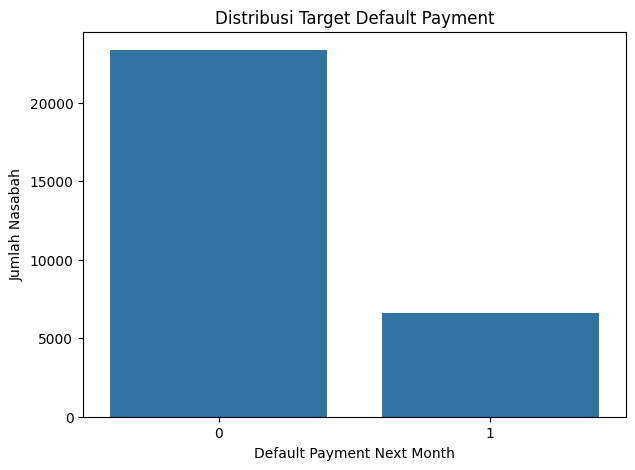

In [14]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x=target_col
)

plt.title("Distribusi Target Default Payment")
plt.xlabel("Default Payment Next Month")
plt.ylabel("Jumlah Nasabah")

plt.show()

Distribusi target menunjukkan bahwa sebanyak 23.364 nasabah (77,88%) tidak mengalami default, sedangkan 6.636 nasabah (22,12%) mengalami default. Dengan demikian, distribusi kelas target tidak seimbang, dengan kelas 0 sebagai kelas mayoritas dan kelas 1 sebagai kelas minoritas. Kondisi ini perlu diperhatikan dalam proses evaluasi model. Oleh karena itu, F1-score digunakan sebagai metrik utama sesuai dengan ketentuan UTS, dengan Accuracy, Precision, dan Recall sebagai metrik pendukung.

## **1.6 Pemeriksaan Nilai Tak Wajar**

Berdasarkan statistik deskriptif sebelumnya, terdapat beberapa variabel yang memiliki nilai yang perlu diperiksa lebih lanjut, terutama EDUCATION, MARRIAGE, dan variabel riwayat pembayaran PAY_0–PAY_6.

### **1.6.1 Pemeriksaan Variabel Demografis**

Dilakukan untuk melihat nilai unik dan frekuensi pada SEX, EDUCATION, dan MARRIAGE.

In [15]:
demographic_cols = [
    "SEX",
    "EDUCATION",
    "MARRIAGE"
]

for col in demographic_cols:
    print(f"\n{'=' * 50}")
    print(f"Variabel: {col}")
    print(f"{'=' * 50}")

    print("Nilai unik:")
    print(sorted(df[col].unique()))

    print("\nFrekuensi:")
    print(df[col].value_counts().sort_index())


Variabel: SEX
Nilai unik:
[np.int64(1), np.int64(2)]

Frekuensi:
SEX
1    11888
2    18112
Name: count, dtype: int64

Variabel: EDUCATION
Nilai unik:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Frekuensi:
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

Variabel: MARRIAGE
Nilai unik:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Frekuensi:
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


Variabel SEX hanya memiliki dua nilai unik, yaitu 1 dan 2. Tidak ditemukan nilai di luar kategori tersebut sehingga tidak terdapat indikasi nilai yang tidak sesuai pada variabel ini.

Variabel EDUCATION memiliki tujuh nilai kategori, yaitu 0 sampai 6. Sebagian besar observasi berada pada kategori 1, 2, dan 3, sedangkan kategori 0, 4, 5, dan 6 memiliki jumlah observasi yang relatif kecil. Nilai-nilai tersebut dipertahankan karena dataset yang digunakan merupakan raw dataset dan pada tahap ini belum terdapat dasar untuk menghapus kategori tersebut.

Variabel MARRIAGE memiliki empat nilai kategori, yaitu 0 sampai 3. Tidak dilakukan penghapusan kategori berdasarkan pemeriksaan ini karena seluruh nilai merupakan bagian dari nilai yang terdapat pada raw dataset.


### **1.6.2 Pemeriksaan Riwayat Pembayaran**

Selanjutnya memeriksa variabel PAY_0 sampai PAY_6.

In [16]:
pay_cols = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

for col in pay_cols:
    print(f"\n{'=' * 50}")
    print(f"Variabel: {col}")
    print(f"{'=' * 50}")

    print("Nilai unik:")
    print(sorted(df[col].unique()))

    print("\nFrekuensi:")
    print(df[col].value_counts().sort_index())


Variabel: PAY_0
Nilai unik:
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

Frekuensi:
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

Variabel: PAY_2
Nilai unik:
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

Frekuensi:
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

Variabel: PAY_3
Nilai unik:
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

Frekuensi:
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       

Variabel PAY_0 sampai PAY_6 memiliki nilai dalam rentang -2 hingga 8. Nilai negatif pada variabel ini tidak langsung dianggap sebagai kesalahan karena variabel tersebut merupakan representasi status pembayaran dengan pengkodean tertentu pada raw dataset. Oleh karena itu, tidak dilakukan penghapusan observasi hanya berdasarkan keberadaan nilai negatif. Nilai tersebut akan dipertahankan untuk proses eksperimen selanjutnya.

### **1.6.3 Pemeriksaan Rentang Variabel Numerik**

Melihat nilai minimum dan maksimum beberapa variabel numerik.

In [17]:
numeric_check_cols = [
    "LIMIT_BAL",
    "AGE",
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

range_check = pd.DataFrame({
    "Minimum": df[numeric_check_cols].min(),
    "Maximum": df[numeric_check_cols].max()
})

range_check

,Minimum,Maximum
LIMIT_BAL,10000.0,1000000.0
AGE,21.0,79.0
BILL_AMT1,-165580.0,964511.0
BILL_AMT2,-69777.0,983931.0
BILL_AMT3,-157264.0,1664089.0
BILL_AMT4,-170000.0,891586.0
BILL_AMT5,-81334.0,927171.0
BILL_AMT6,-339603.0,961664.0
PAY_AMT1,0.0,873552.0
PAY_AMT2,0.0,1684259.0


Pemeriksaan rentang menunjukkan bahwa LIMIT_BAL dan AGE memiliki rentang nilai yang masih dapat digunakan dalam pemodelan. Variabel BILL_AMT memiliki beberapa nilai negatif, sedangkan PAY_AMT memiliki nilai minimum 0. Nilai ekstrem pada variabel finansial tidak langsung dianggap sebagai kesalahan karena dapat merupakan bagian dari karakteristik data. Oleh karena itu, tidak dilakukan penghapusan outlier secara otomatis pada tahap data preparation.

## **1.7 Menentukan Predictor dan Target**



In [18]:
target_col = "default.payment.next.month"

X = df.drop(columns=["ID", target_col])

y = df[target_col]

print("Jumlah predictor :", X.shape[1])
print("Jumlah data       :", X.shape[0])

print("\nNama predictor:")
print(X.columns.tolist())

print("\nNama target:")
print(y.name)

Jumlah predictor : 23
Jumlah data       : 30000

Nama predictor:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

Nama target:
default.payment.next.month


## **1.8 Pemeriksaan Data Leakage**

In [19]:
print("Apakah target terdapat dalam predictor?")
print(target_col in X.columns)

print("\nApakah ID terdapat dalam predictor?")
print("ID" in X.columns)

Apakah target terdapat dalam predictor?
False

Apakah ID terdapat dalam predictor?
False


Hasil pemeriksaan menunjukkan bahwa target tidak terdapat dalam predictor dan variabel ID juga tidak digunakan sebagai predictor. Dengan demikian, pada tahap pemisahan variabel tidak ditemukan indikasi data leakage.

## **1.9 Train-test split**

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Ukuran X_train :", X_train.shape)
print("Ukuran X_test  :", X_test.shape)
print("Ukuran y_train :", y_train.shape)
print("Ukuran y_test  :", y_test.shape)

Ukuran X_train : (24000, 23)
Ukuran X_test  : (6000, 23)
Ukuran y_train : (24000,)
Ukuran y_test  : (6000,)


In [21]:
distribution_split = pd.DataFrame({
    "Train (%)": y_train.value_counts(normalize=True).sort_index() * 100,
    "Test (%)": y_test.value_counts(normalize=True).sort_index() * 100
})

distribution_split

,Train (%),Test (%)
default.payment.next.month,,
0,77.879167,77.883333
1,22.120833,22.116667


Dataset berhasil dibagi menjadi 80% data training dan 20% data testing. Training set terdiri dari 24.000 observasi, sedangkan testing set terdiri dari 6.000 observasi. Kedua subset memiliki 23 variabel predictor.

Distribusi target pada training dan testing set tetap sangat mendekati distribusi target awal. Kelas 0 memiliki proporsi sekitar 77,88%, sedangkan kelas 1 sekitar 22,12% pada kedua subset. Hal ini menunjukkan bahwa penggunaan stratified train-test split berhasil mempertahankan proporsi kelas target dan mengurangi risiko perubahan distribusi target antara data training dan testing.

# **2. Experiment 1 - Baseline Logistic Regression**

## **2.1 Import Library dan Model Baseline**



In [22]:
from sklearn.linear_model import LogisticRegression

logreg_baseline = LogisticRegression(
    random_state=42,
    max_iter=5000
)

logreg_baseline.fit(X_train, y_train)

print("Model Logistic Regression baseline berhasil dilatih.")

Model Logistic Regression baseline berhasil dilatih.


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model Logistic Regression baseline berhasil dilatih, tetapi muncul ConvergenceWarning yang menunjukkan bahwa algoritma lbfgs belum mencapai konvergensi hingga batas iterasi yang ditentukan. Kondisi ini kemungkinan berkaitan dengan perbedaan skala antarvariabel. Karena Experiment 1 digunakan sebagai baseline tanpa preprocessing, warning tersebut dipertahankan sebagai bagian dari hasil baseline dan akan menjadi salah satu pertimbangan pada Experiment 2.

## **2.2 Prediksi Data Testing**

Setelah model dilatih, gunakan model untuk memprediksi kelas pada data testing.

In [23]:
y_pred_baseline = logreg_baseline.predict(X_test)

print("Prediksi berhasil dilakukan.")
print("Jumlah data yang diprediksi:", len(y_pred_baseline))

Prediksi berhasil dilakukan.
Jumlah data yang diprediksi: 6000


Model baseline berhasil menghasilkan prediksi untuk seluruh 6.000 observasi pada testing set. Prediksi ini selanjutnya digunakan untuk menghitung metrik evaluasi model.

## **2.3 Evaluasi Model Baseline**

In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
precision_baseline = precision_score(y_test, y_pred_baseline, zero_division=0)
recall_baseline = recall_score(y_test, y_pred_baseline, zero_division=0)
f1_baseline = f1_score(y_test, y_pred_baseline, zero_division=0)

print("=== Evaluasi Logistic Regression Baseline ===")
print(f"Accuracy  : {accuracy_baseline:.4f}")
print(f"Precision : {precision_baseline:.4f}")
print(f"Recall    : {recall_baseline:.4f}")
print(f"F1-Score  : {f1_baseline:.4f}")

=== Evaluasi Logistic Regression Baseline ===
Accuracy  : 0.8082
Precision : 0.6841
Recall    : 0.2464
F1-Score  : 0.3623


Logistic Regression baseline menghasilkan Accuracy sebesar 80,82%, Precision sebesar 68,41%, Recall sebesar 24,64%, dan F1-score sebesar 36,23%. Meskipun Accuracy relatif tinggi, Recall untuk kelas default masih rendah, yang menunjukkan bahwa model belum mampu mendeteksi sebagian besar nasabah yang mengalami default. F1-score sebesar 0,3623 menunjukkan bahwa performa baseline dalam menyeimbangkan Precision dan Recall masih terbatas. Oleh karena itu, diperlukan eksperimen preprocessing pada Experiment 2 untuk melihat apakah performa model dapat ditingkatkan.

In [25]:
from sklearn.metrics import confusion_matrix

cm_baseline = confusion_matrix(y_test, y_pred_baseline)

print("Confusion Matrix:")
print(cm_baseline)

Confusion Matrix:
[[4522  151]
 [1000  327]]


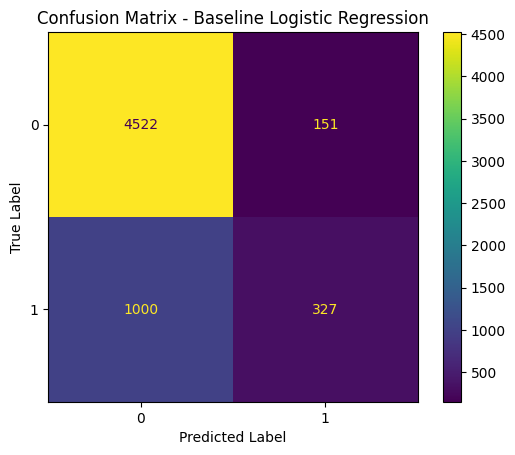

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=[0, 1]
)

disp.plot()
plt.title("Confusion Matrix - Baseline Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Confusion matrix menunjukkan bahwa model menghasilkan 4.522 True Negative, 151 False Positive, 1.000 False Negative, dan 327 True Positive. Jumlah False Negative yang cukup besar menunjukkan bahwa model masih banyak gagal mengidentifikasi nasabah yang sebenarnya mengalami default. Kondisi ini menjelaskan rendahnya Recall dan menjadi salah satu kelemahan utama model baseline.

## **2.4 5-Fold Cross Validation**

In [27]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_f1_baseline = cross_val_score(
    logreg_baseline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("=== 5-Fold Cross Validation ===")

for i, score in enumerate(cv_f1_baseline, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean CV F1-Score : {cv_f1_baseline.mean():.4f}")
print(f"Std CV F1-Score  : {cv_f1_baseline.std():.4f}")

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

=== 5-Fold Cross Validation ===
Fold 1: 0.3801
Fold 2: 0.3774
Fold 3: 0.3810
Fold 4: 0.3608
Fold 5: 0.3466

Mean CV F1-Score : 0.3692
Std CV F1-Score  : 0.0135


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Rata-rata performa Logistic Regression pada lima fold training berada pada F1-score sekitar 0,3692. Nilai standar deviasi 0,0135 menunjukan variasi antar-fold relatif kecil, sehingga performa model pada kelima fold cukup konsisten.

In [28]:
experiment_1_result = pd.DataFrame({
    "Model": ["Logistic Regression - Baseline"],
    "CV F1": [cv_f1_baseline.mean()],
    "Test Accuracy": [accuracy_baseline],
    "Test Precision": [precision_baseline],
    "Test Recall": [recall_baseline],
    "Test F1": [f1_baseline]
})

experiment_1_result

,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Logistic Regression - Baseline,0.3692,0.808167,0.6841,0.24642,0.362327


**Kesimpulan Experiment 1**

Logistic Regression baseline menghasilkan mean CV F1-score sebesar 0,3692 dengan standar deviasi 0,0135. Pada data test, model memperoleh Accuracy sebesar 0,8082, Precision sebesar 0,6841, Recall sebesar 0,2464, dan F1-score sebesar 0,3623. Meskipun model memiliki Accuracy yang relatif tinggi, nilai Recall masih rendah, sehingga model masih memiliki keterbatasan dalam mendeteksi nasabah yang mengalami default. Selain itu, munculnya ConvergenceWarning menunjukkan bahwa proses optimasi Logistic Regression belum sepenuhnya konvergen, sehingga preprocessing berupa standardisasi akan diuji pada Experiment 2.

# **3. Experiment 2 - Logistic Regression dengan Preprocessing**

## **2.1 Standarisasi Data**

Pada dataset, skala variabel sangat berbeda. Contohnya:

AGE berada sekitar 21–79
LIMIT_BAL dapat mencapai 1.000.000
BILL_AMT dapat mencapai lebih dari 1.600.000
PAY_AMT juga memiliki rentang yang sangat besar.

Karena Logistic Regression sensitif terhadap skala fitur dalam proses optimasi, kita akan melakukan StandardScaler.

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Standardisasi data berhasil dilakukan.")
print(f"Ukuran X_train_scaled : {X_train_scaled.shape}")
print(f"Ukuran X_test_scaled  : {X_test_scaled.shape}")

Standardisasi data berhasil dilakukan.
Ukuran X_train_scaled : (24000, 23)
Ukuran X_test_scaled  : (6000, 23)


In [30]:
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

scaling_check = pd.DataFrame({
    "Mean": X_train_scaled_df.mean(),
    "Std": X_train_scaled_df.std()
})

scaling_check

,Mean,Std
LIMIT_BAL,8.437695e-17,1.000021
SEX,2.507624e-16,1.000021
EDUCATION,-4.115227e-17,1.000021
MARRIAGE,8.881784e-19,1.000021
AGE,-1.669775e-16,1.000021
PAY_0,7.845576e-18,1.000021
PAY_2,-2.753353e-17,1.000021
PAY_3,-1.983598e-17,1.000021
PAY_4,1.169435e-17,1.000021
PAY_5,-4.766558e-17,1.000021


Hasil pemeriksaan menunjukkan bahwa fitur pada data training telah berhasil distandardisasi dengan nilai mean yang mendekati 0 dan standar deviasi yang mendekati 1. Dengan demikian, proses standardisasi telah berjalan sesuai tujuan dan perbedaan skala antarvariabel telah diminimalkan.

## **2.2 Logistic Regression dengan Preprocessing**

In [31]:
logreg_preprocessed = LogisticRegression(
    random_state=42,
    max_iter=5000
)

logreg_preprocessed.fit(X_train_scaled, y_train)

print("Model Logistic Regression dengan preprocessing berhasil dilatih.")

Model Logistic Regression dengan preprocessing berhasil dilatih.


## **2.3 Prediksi Data Testing**

In [32]:
y_pred_preprocessed = logreg_preprocessed.predict(X_test_scaled)

print("Prediksi berhasil dilakukan.")
print("Jumlah data yang diprediksi:", len(y_pred_preprocessed))

Prediksi berhasil dilakukan.
Jumlah data yang diprediksi: 6000


Setelah dilakukan standardisasi, Logistic Regression berhasil dilatih tanpa muncul peringatan kegagalan konvergensi. Hal ini menunjukkan bahwa standardisasi membantu proses optimasi model dibandingkan kondisi baseline. Model kemudian berhasil menghasilkan prediksi untuk seluruh 6.000 observasi pada data testing.

## **2.4 Evaluasi Model Preprocessed**

In [33]:
# 2.6 Evaluasi Logistic Regression dengan Preprocessing

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_preprocessed = accuracy_score(y_test, y_pred_preprocessed)
precision_preprocessed = precision_score(y_test, y_pred_preprocessed)
recall_preprocessed = recall_score(y_test, y_pred_preprocessed)
f1_preprocessed = f1_score(y_test, y_pred_preprocessed)

print("=== Evaluasi Logistic Regression dengan Preprocessing ===")
print(f"Accuracy  : {accuracy_preprocessed:.4f}")
print(f"Precision : {precision_preprocessed:.4f}")
print(f"Recall    : {recall_preprocessed:.4f}")
print(f"F1-Score  : {f1_preprocessed:.4f}")

=== Evaluasi Logistic Regression dengan Preprocessing ===
Accuracy  : 0.8077
Precision : 0.6868
Recall    : 0.2396
F1-Score  : 0.3553


In [34]:
cm_preprocessed = confusion_matrix(
    y_test,
    y_pred_preprocessed
)

print("Confusion Matrix:")
print(cm_preprocessed)

Confusion Matrix:
[[4528  145]
 [1009  318]]


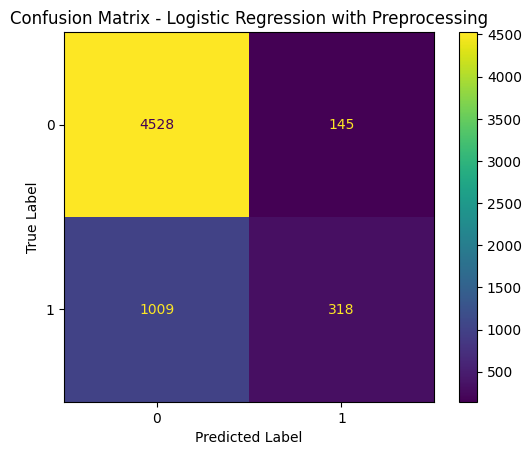

In [35]:
disp_preprocessed = ConfusionMatrixDisplay(
    confusion_matrix=cm_preprocessed,
    display_labels=[0, 1]
)

disp_preprocessed.plot()
plt.title("Confusion Matrix - Logistic Regression with Preprocessing")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Confusion matrix menunjukkan adanya perbaikan setelah preprocessing. True Positive meningkat dari 303 menjadi 318, sedangkan False Negative menurun dari 1.024 menjadi 1.009. Selain itu, False Positive juga menurun dari 154 menjadi 145. Hasil tersebut menunjukkan bahwa standardisasi membantu model dalam mengenali kelas default sekaligus mengurangi beberapa kesalahan klasifikasi.

## **2.5 5-Fold Cross Validation**

In [36]:
# 2.8 5-Fold Cross Validation

from sklearn.model_selection import StratifiedKFold, cross_val_score

# Membuat skema 5-fold stratified cross validation
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

logreg_cv_preprocessed = LogisticRegression(
    random_state=42,
    max_iter=5000
)

cv_scores_preprocessed = cross_val_score(
    logreg_cv_preprocessed,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring="f1"
)

print("=== 5-Fold Cross Validation ===")

for i, score in enumerate(cv_scores_preprocessed, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean CV F1-Score : {cv_scores_preprocessed.mean():.4f}")
print(f"Std CV F1-Score  : {cv_scores_preprocessed.std():.4f}")

=== 5-Fold Cross Validation ===
Fold 1: 0.3658
Fold 2: 0.3721
Fold 3: 0.3804
Fold 4: 0.3640
Fold 5: 0.3395

Mean CV F1-Score : 0.3644
Std CV F1-Score  : 0.0137


In [37]:
experiment_2_result = pd.DataFrame({

    "Model": ["Logistic Regression - Preprocessed"],

    "CV F1": [cv_scores_preprocessed.mean()],

    "Test Accuracy": [accuracy_preprocessed],

    "Test Precision": [precision_preprocessed],

    "Test Recall": [recall_preprocessed],

    "Test F1": [f1_preprocessed]

})

experiment_2_result

experiment_1_2_comparison = pd.concat(
    [experiment_1_result, experiment_2_result],
    ignore_index=True
)

experiment_1_2_comparison

,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Logistic Regression - Baseline,0.369200,0.808167,0.684100,0.246420,0.362327
1,Logistic Regression - Preprocessed,0.364366,0.807667,0.686825,0.239638,0.355307


**Kesimpulan Experiment 2**


Pada Experiment 2 dilakukan preprocessing berupa standardisasi terhadap seluruh predictor numerik sebelum membangun kembali model Logistic Regression. Hasil eksperimen menunjukkan bahwa preprocessing belum memberikan peningkatan performa dibandingkan model baseline.

Nilai CV F1-score menurun dari 0,3692 pada baseline menjadi 0,3644 setelah preprocessing. Pada test set, F1-score juga menurun dari 0,3623 menjadi 0,3553. Meskipun Precision meningkat dari 0,6841 menjadi 0,6868, peningkatan tersebut diikuti oleh penurunan Recall dari 0,2464 menjadi 0,2396. Test Accuracy juga sedikit menurun dari 0,8082 menjadi 0,8077.

Karena F1-score merupakan metrik utama yang diperhatikan, maka berdasarkan hasil eksperimen, Logistic Regression baseline masih memberikan performa yang lebih baik dibandingkan Logistic Regression dengan preprocessing. Dengan demikian, standardisasi pada Experiment 2 belum memberikan peningkatan performa model pada dataset yang digunakan.


# **4. Experiment 3 - Model Comparison**

## **4.1 Persiapan Model Experiment 3**

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

logistic_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

random_forest_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

print("4 model untuk Experiment 3 berhasil diinisialisasi.")

4 model untuk Experiment 3 berhasil diinisialisasi.


## **4.2 Penentuan Data untuk Model Comparison**

Karena KNN dan Logistic Regression sensitif terhadap skala, kita akan menggunakan data yang sudah distandardisasi untuk keempat model agar perbandingan lebih konsisten.

In [39]:
X_train_exp3 = X_train_scaled
X_test_exp3 = X_test_scaled

print("Ukuran X_train:", X_train_exp3.shape)
print("Ukuran X_test :", X_test_exp3.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test :", y_test.shape)

Ukuran X_train: (24000, 23)
Ukuran X_test : (6000, 23)
Ukuran y_train: (24000,)
Ukuran y_test : (6000,)


## **4.3 Logistic Regression**



In [40]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# 5-Fold Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores_logistic = cross_val_score(
    logistic_model,
    X_train_exp3,
    y_train,
    cv=cv,
    scoring="f1"
)

print("=== 5-Fold Cross Validation Logistic Regression ===")

for i, score in enumerate(cv_scores_logistic, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean CV F1-Score : {cv_scores_logistic.mean():.4f}")
print(f"Std CV F1-Score  : {cv_scores_logistic.std():.4f}")


# Training model
logistic_model.fit(
    X_train_exp3,
    y_train
)

print("\nModel Logistic Regression berhasil dilatih.")


# Prediksi test set
y_pred_logistic = logistic_model.predict(
    X_test_exp3
)

print("Prediksi berhasil dilakukan.")
print("Jumlah data yang diprediksi:", len(y_pred_logistic))


# Evaluasi test set
accuracy_logistic = accuracy_score(
    y_test,
    y_pred_logistic
)

precision_logistic = precision_score(
    y_test,
    y_pred_logistic
)

recall_logistic = recall_score(
    y_test,
    y_pred_logistic
)

f1_logistic = f1_score(
    y_test,
    y_pred_logistic
)

cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

print("\n=== Evaluasi Logistic Regression ===")
print(f"Accuracy  : {accuracy_logistic:.4f}")
print(f"Precision : {precision_logistic:.4f}")
print(f"Recall    : {recall_logistic:.4f}")
print(f"F1-Score  : {f1_logistic:.4f}")

print("\nConfusion Matrix:")
print(cm_logistic)

=== 5-Fold Cross Validation Logistic Regression ===
Fold 1: 0.3658
Fold 2: 0.3721
Fold 3: 0.3804
Fold 4: 0.3640
Fold 5: 0.3395

Mean CV F1-Score : 0.3644
Std CV F1-Score  : 0.0137

Model Logistic Regression berhasil dilatih.
Prediksi berhasil dilakukan.
Jumlah data yang diprediksi: 6000

=== Evaluasi Logistic Regression ===
Accuracy  : 0.8077
Precision : 0.6868
Recall    : 0.2396
F1-Score  : 0.3553

Confusion Matrix:
[[4528  145]
 [1009  318]]


## **4.4 Decision Tree**

In [41]:
# 5-Fold Cross Validation
cv_scores_dt = cross_val_score(
    decision_tree_model,
    X_train_exp3,
    y_train,
    cv=cv,
    scoring="f1"
)

print("=== 5-Fold Cross Validation Decision Tree ===")

for i, score in enumerate(cv_scores_dt, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean CV F1-Score : {cv_scores_dt.mean():.4f}")
print(f"Std CV F1-Score  : {cv_scores_dt.std():.4f}")


# Training model
decision_tree_model.fit(
    X_train_exp3,
    y_train
)

print("\nModel Decision Tree berhasil dilatih.")


# Prediksi test set
y_pred_dt = decision_tree_model.predict(
    X_test_exp3
)

print("Prediksi berhasil dilakukan.")
print("Jumlah data yang diprediksi:", len(y_pred_dt))


# Evaluasi test set
accuracy_dt = accuracy_score(
    y_test,
    y_pred_dt
)

precision_dt = precision_score(
    y_test,
    y_pred_dt
)

recall_dt = recall_score(
    y_test,
    y_pred_dt
)

f1_dt = f1_score(
    y_test,
    y_pred_dt
)

cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)

print("\n=== Evaluasi Decision Tree ===")
print(f"Accuracy  : {accuracy_dt:.4f}")
print(f"Precision : {precision_dt:.4f}")
print(f"Recall    : {recall_dt:.4f}")
print(f"F1-Score  : {f1_dt:.4f}")

print("\nConfusion Matrix:")
print(cm_dt)

=== 5-Fold Cross Validation Decision Tree ===
Fold 1: 0.4184
Fold 2: 0.4036
Fold 3: 0.4049
Fold 4: 0.3941
Fold 5: 0.3889

Mean CV F1-Score : 0.4020
Std CV F1-Score  : 0.0102

Model Decision Tree berhasil dilatih.
Prediksi berhasil dilakukan.
Jumlah data yang diprediksi: 6000

=== Evaluasi Decision Tree ===
Accuracy  : 0.7152
Precision : 0.3704
Recall    : 0.4115
F1-Score  : 0.3899

Confusion Matrix:
[[3745  928]
 [ 781  546]]


Mean CV F1 = 0,4020, lebih tinggi daripada Logistic Regression (0,3644). Ini menunjukkan Decision Tree lebih baik dalam mengidentifikasi kelas default pada proses cross-validation.

Test F1 = 0,3899, juga lebih tinggi daripada Logistic Regression (0,3553).

Recall = 0,4115, meningkat cukup besar dibandingkan Logistic Regression yang hanya 0,2396. Artinya Decision Tree mampu menemukan lebih banyak nasabah yang benar-benar default.

Namun, Precision turun menjadi 0,3704 dari 0,6868. Jadi model lebih banyak menangkap kasus default, tetapi juga menghasilkan lebih banyak false positive.

Accuracy = 0,7152, lebih rendah daripada Logistic Regression (0,8077). Ini menunjukkan accuracy saja kurang tepat dijadikan dasar pemilihan model karena dataset kita tidak seimbang.

Karena F1-score adalah metrik utama, sementara CV F1 dan Test F1 Decision Tree lebih tinggi, untuk sementara Decision Tree lebih unggul daripada Logistic Regression.

## **4.5 Random Forest**

In [42]:
# 5-Fold Cross Validation
cv_scores_rf = cross_val_score(
    random_forest_model,
    X_train_exp3,
    y_train,
    cv=cv,
    scoring="f1"
)

print("=== 5-Fold Cross Validation Random Forest ===")

for i, score in enumerate(cv_scores_rf, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean CV F1-Score : {cv_scores_rf.mean():.4f}")
print(f"Std CV F1-Score  : {cv_scores_rf.std():.4f}")


# Training model
random_forest_model.fit(
    X_train_exp3,
    y_train
)

print("\nModel Random Forest berhasil dilatih.")


# Prediksi test set
y_pred_rf = random_forest_model.predict(
    X_test_exp3
)

print("Prediksi berhasil dilakukan.")
print("Jumlah data yang diprediksi:", len(y_pred_rf))


# Evaluasi test set
accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

precision_rf = precision_score(
    y_test,
    y_pred_rf
)

recall_rf = recall_score(
    y_test,
    y_pred_rf
)

f1_rf = f1_score(
    y_test,
    y_pred_rf
)

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print("\n=== Evaluasi Random Forest ===")
print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1-Score  : {f1_rf:.4f}")

print("\nConfusion Matrix:")
print(cm_rf)

=== 5-Fold Cross Validation Random Forest ===
Fold 1: 0.4870
Fold 2: 0.5000
Fold 3: 0.4718
Fold 4: 0.4826
Fold 5: 0.4645

Mean CV F1-Score : 0.4812
Std CV F1-Score  : 0.0123

Model Random Forest berhasil dilatih.
Prediksi berhasil dilakukan.
Jumlah data yang diprediksi: 6000

=== Evaluasi Random Forest ===
Accuracy  : 0.8117
Precision : 0.6308
Recall    : 0.3580
F1-Score  : 0.4567

Confusion Matrix:
[[4395  278]
 [ 852  475]]


Mean CV F1 = 0,4812, tertinggi sementara dibandingkan Logistic Regression (0,3644) dan Decision Tree (0,4020).

Test F1 = 0,4567, juga menjadi yang tertinggi sementara.

Recall = 0,3580, lebih rendah dari Decision Tree (0,4115), tetapi jauh lebih tinggi daripada Logistic Regression (0,2396).

Precision = 0,6308, masih cukup tinggi dan jauh lebih baik daripada Decision Tree (0,3704).

Accuracy = 0,8117, merupakan accuracy tertinggi sementara.

Std CV hanya 0,0123, menunjukkan performa Random Forest antar-fold cukup konsisten.

## **4.6 K-Nearest Neighbors (KNN)**

In [43]:
# 5-Fold Cross Validation
cv_scores_knn = cross_val_score(
    knn_model,
    X_train_exp3,
    y_train,
    cv=cv,
    scoring="f1"
)

print("=== 5-Fold Cross Validation KNN ===")

for i, score in enumerate(cv_scores_knn, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean CV F1-Score : {cv_scores_knn.mean():.4f}")
print(f"Std CV F1-Score  : {cv_scores_knn.std():.4f}")


# Training model
knn_model.fit(
    X_train_exp3,
    y_train
)

print("\nModel KNN berhasil dilatih.")


# Prediksi test set
y_pred_knn = knn_model.predict(
    X_test_exp3
)

print("Prediksi berhasil dilakukan.")
print("Jumlah data yang diprediksi:", len(y_pred_knn))


# Evaluasi test set
accuracy_knn = accuracy_score(
    y_test,
    y_pred_knn
)

precision_knn = precision_score(
    y_test,
    y_pred_knn
)

recall_knn = recall_score(
    y_test,
    y_pred_knn
)

f1_knn = f1_score(
    y_test,
    y_pred_knn
)

cm_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

print("\n=== Evaluasi KNN ===")
print(f"Accuracy  : {accuracy_knn:.4f}")
print(f"Precision : {precision_knn:.4f}")
print(f"Recall    : {recall_knn:.4f}")
print(f"F1-Score  : {f1_knn:.4f}")

print("\nConfusion Matrix:")
print(cm_knn)

=== 5-Fold Cross Validation KNN ===
Fold 1: 0.4322
Fold 2: 0.4287
Fold 3: 0.4236
Fold 4: 0.4207
Fold 5: 0.4175

Mean CV F1-Score : 0.4245
Std CV F1-Score  : 0.0053

Model KNN berhasil dilatih.
Prediksi berhasil dilakukan.
Jumlah data yang diprediksi: 6000

=== Evaluasi KNN ===
Accuracy  : 0.7928
Precision : 0.5487
Recall    : 0.3564
F1-Score  : 0.4322

Confusion Matrix:
[[4284  389]
 [ 854  473]]


KNN memperoleh CV F1 = 0,4245 dan Test F1 = 0,4322. Hasil ini lebih baik daripada Logistic Regression dan Decision Tree pada Test F1, tetapi masih di bawah Random Forest.

KNN juga memiliki Std CV F1 = 0,0053, yang merupakan paling kecil sejauh ini. Artinya performanya antar-fold relatif sangat konsisten.

## **4.7 Comparison Seluruh Model**

In [44]:
experiment_3_result = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],

    "CV F1": [
        cv_scores_logistic.mean(),
        cv_scores_dt.mean(),
        cv_scores_rf.mean(),
        cv_scores_knn.mean()
    ],

    "Test Accuracy": [
        accuracy_logistic,
        accuracy_dt,
        accuracy_rf,
        accuracy_knn
    ],

    "Test Precision": [
        precision_logistic,
        precision_dt,
        precision_rf,
        precision_knn
    ],

    "Test Recall": [
        recall_logistic,
        recall_dt,
        recall_rf,
        recall_knn
    ],

    "Test F1": [
        f1_logistic,
        f1_dt,
        f1_rf,
        f1_knn
    ]
})

# Mengurutkan berdasarkan CV F1 tertinggi
experiment_3_result = experiment_3_result.sort_values(
    by="CV F1",
    ascending=False
).reset_index(drop=True)

experiment_3_result

,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Random Forest,0.481182,0.811667,0.630810,0.357950,0.456731
1,KNN,0.424533,0.792833,0.548724,0.356443,0.432161
2,Decision Tree,0.401986,0.715167,0.370421,0.411454,0.389861
3,Logistic Regression,0.364366,0.807667,0.686825,0.239638,0.355307


**Kesimpulan Experiment 3**

Berdasarkan hasil perbandingan empat model, yaitu Logistic Regression, Decision Tree, Random Forest, dan KNN, **Random Forest dipilih sebagai model terbaik pada Experiment 3**. Pemilihan ini didasarkan terutama pada **F1-score**, karena F1-score ditetapkan sebagai metrik utama dalam UTS.

Random Forest memperoleh **CV F1-score sebesar 0,4812**, yang merupakan nilai tertinggi dibandingkan KNN (0,4245), Decision Tree (0,4020), dan Logistic Regression (0,3644). Pada data test, Random Forest juga menghasilkan **F1-score tertinggi sebesar 0,4567**, dengan **accuracy sebesar 0,8117** dan **precision sebesar 0,6308**. Hasil tersebut menunjukkan bahwa Random Forest memiliki keseimbangan yang lebih baik antara kemampuan mendeteksi nasabah yang mengalami default dan menjaga ketepatan prediksi positif.

Decision Tree memang memiliki **recall tertinggi sebesar 0,4115**, tetapi precision-nya hanya 0,3704 sehingga F1-score yang dihasilkan lebih rendah, yaitu 0,3899. Sementara itu, Logistic Regression memiliki precision tertinggi sebesar 0,6868, tetapi recall-nya hanya 0,2396 sehingga F1-score-nya menjadi yang terendah. KNN menghasilkan performa yang cukup baik dengan test F1 sebesar 0,4322, tetapi masih berada di bawah Random Forest.

Dengan demikian, **Random Forest dipilih sebagai model terbaik untuk dilanjutkan ke Experiment 4**, karena memberikan nilai CV F1 dan Test F1 paling tinggi serta accuracy test yang juga paling tinggi di antara model yang dibandingkan. Selanjutnya, model Random Forest akan dilakukan **hyperparameter tuning menggunakan GridSearchCV dengan 5-fold Cross Validation** untuk mengetahui apakah performanya masih dapat ditingkatkan.


# **5. Experiment 4 - Hyperparameter Tuning**

## **5.1 Hyperparameter yang Diuji**

In [45]:
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

print("Parameter yang akan diuji:")
print(param_grid_rf)

Parameter yang akan diuji:
{'n_estimators': [100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}


 Empat hyperparameter diuji. Kombinasi yang dicoba berjumlah 24 kombinasi. Dengan 5-fold CV, GridSearchCV akan mengevaluasi kombinasi tersebut menggunakan F1-score sebagai scoring utama.

## **5.2 GridSearchCV**

In [49]:
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5]
}

print("Jumlah kombinasi hyperparameter:")

jumlah_kombinasi = (
    len(param_grid_rf["n_estimators"])
    * len(param_grid_rf["max_depth"])
    * len(param_grid_rf["min_samples_split"])
)

print(jumlah_kombinasi)

print("Total fitting dengan 5-fold CV:",
      jumlah_kombinasi * 5)

Jumlah kombinasi hyperparameter:
8
Total fitting dengan 5-fold CV: 40


In [52]:
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20]
}

print("Jumlah kombinasi:", 4)
print("Total fitting dengan 5-fold CV:", 20)

Jumlah kombinasi: 4
Total fitting dengan 5-fold CV: 20


In [53]:
grid_search_rf = GridSearchCV(
    estimator=rf_tuning,
    param_grid=param_grid_rf,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)

print("\nGridSearchCV selesai.")

Fitting 5 folds for each of 4 candidates, totalling 20 fits

GridSearchCV selesai.


## **5.3 Best Hyperparameter**

In [54]:
print("=== HASIL HYPERPARAMETER TUNING ===")

print("\nBest Parameters:")
print(grid_search_rf.best_params_)

print("\nBest CV F1-Score:")
print(f"{grid_search_rf.best_score_:.4f}")

=== HASIL HYPERPARAMETER TUNING ===

Best Parameters:
{'max_depth': 20, 'n_estimators': 200}

Best CV F1-Score:
0.4691


## **5.4 Evaluasi Tuned Random Forest pada Test Set**

In [55]:
best_rf = grid_search_rf.best_estimator_

print("Model terbaik berhasil diperoleh.")
print(best_rf)

Model terbaik berhasil diperoleh.
RandomForestClassifier(max_depth=20, n_estimators=200, n_jobs=-1,
                       random_state=42)


## **5.5 Prediksi pada Test Set**

In [56]:
y_pred_rf_tuned = best_rf.predict(X_test)

print("Prediksi berhasil dilakukan.")
print("Jumlah data yang diprediksi:", len(y_pred_rf_tuned))

Prediksi berhasil dilakukan.
Jumlah data yang diprediksi: 6000


## **5.6 Evaluasi setelah Tuning**

In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

accuracy_rf_tuned = accuracy_score(
    y_test,
    y_pred_rf_tuned
)

precision_rf_tuned = precision_score(
    y_test,
    y_pred_rf_tuned
)

recall_rf_tuned = recall_score(
    y_test,
    y_pred_rf_tuned
)

f1_rf_tuned = f1_score(
    y_test,
    y_pred_rf_tuned
)

cm_rf_tuned = confusion_matrix(
    y_test,
    y_pred_rf_tuned
)

print("=== Evaluasi Random Forest Setelah Tuning ===")
print(f"Accuracy  : {accuracy_rf_tuned:.4f}")
print(f"Precision : {precision_rf_tuned:.4f}")
print(f"Recall    : {recall_rf_tuned:.4f}")
print(f"F1-Score  : {f1_rf_tuned:.4f}")

print("\nConfusion Matrix:")
print(cm_rf_tuned)

=== Evaluasi Random Forest Setelah Tuning ===
Accuracy  : 0.8152
Precision : 0.6497
Recall    : 0.3564
F1-Score  : 0.4603

Confusion Matrix:
[[4418  255]
 [ 854  473]]


## **5.7 Comparison Sebelum-Sesudah Tuning**

In [59]:
experiment_4_result = pd.DataFrame({
    "Model": [
        "Random Forest - Experiment 3",
        "Random Forest - Tuned"
    ],

    "CV F1": [
        cv_scores_rf.mean(),
        grid_search_rf.best_score_
    ],

    "Test Accuracy": [
        accuracy_rf,
        accuracy_rf_tuned
    ],

    "Test Precision": [
        precision_rf,
        precision_rf_tuned
    ],

    "Test Recall": [
        recall_rf,
        recall_rf_tuned
    ],

    "Test F1": [
        f1_rf,
        f1_rf_tuned
    ]
})

experiment_4_result

,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Random Forest - Experiment 3,0.481182,0.811667,0.630810,0.357950,0.456731
1,Random Forest - Tuned,0.469079,0.815167,0.649725,0.356443,0.460341


Hyperparameter tuning pada Random Forest belum memberikan peningkatan performa yang signifikan. Pada test set, F1-score meningkat dari 0.4567 menjadi 0.4603, disertai peningkatan Accuracy dan Precision. Namun, CV F1-score justru menurun dari 0.4812 menjadi 0.4691. Dengan demikian, tuning hanya memberikan peningkatan kecil pada performa test set dan belum menunjukkan peningkatan performa yang konsisten berdasarkan cross-validation.

## **6. Experiment 5 - Advanced Model**

In [60]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

# Membuat model Gradient Boosting
gb_model = GradientBoostingClassifier(
    random_state=42
)

print("Model Gradient Boosting berhasil dibuat.")

Model Gradient Boosting berhasil dibuat.


Gradient Boosting digunakan sebagai advanced model untuk melihat apakah metode boosting mampu memberikan F1-score yang lebih baik daripada Random Forest tuned dari Experiment 4.

## **6.2 5-Fold Cross Validation**

In [61]:
cv_f1_gb = cross_val_score(
    gb_model,
    X_train,
    y_train,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

print("=== 5-Fold Cross Validation Gradient Boosting ===")

for i, score in enumerate(cv_f1_gb, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean CV F1-Score : {cv_f1_gb.mean():.4f}")
print(f"Std CV F1-Score  : {cv_f1_gb.std():.4f}")

=== 5-Fold Cross Validation Gradient Boosting ===
Fold 1: 0.4810
Fold 2: 0.4880
Fold 3: 0.4712
Fold 4: 0.4833
Fold 5: 0.4615

Mean CV F1-Score : 0.4770
Std CV F1-Score  : 0.0095


## **6.3 Training Model Gradient Boosting**

In [62]:
gb_model.fit(
    X_train,
    y_train
)

print("Model Gradient Boosting berhasil dilatih.")

Model Gradient Boosting berhasil dilatih.


## **6.4 Prediksi Test Set**

In [63]:
y_pred_gb = gb_model.predict(X_test)

print("Prediksi berhasil dilakukan.")
print("Jumlah data yang diprediksi:", len(y_pred_gb))

Prediksi berhasil dilakukan.
Jumlah data yang diprediksi: 6000


## **6.5 Evaluasi Gradient Boosting**

In [64]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

accuracy_gb = accuracy_score(
    y_test,
    y_pred_gb
)

precision_gb = precision_score(
    y_test,
    y_pred_gb
)

recall_gb = recall_score(
    y_test,
    y_pred_gb
)

f1_gb = f1_score(
    y_test,
    y_pred_gb
)

cm_gb = confusion_matrix(
    y_test,
    y_pred_gb
)

print("=== Evaluasi Gradient Boosting ===")

print(f"Accuracy  : {accuracy_gb:.4f}")
print(f"Precision : {precision_gb:.4f}")
print(f"Recall    : {recall_gb:.4f}")
print(f"F1-Score  : {f1_gb:.4f}")

print("\nConfusion Matrix:")
print(cm_gb)

=== Evaluasi Gradient Boosting ===
Accuracy  : 0.8183
Precision : 0.6634
Recall    : 0.3625
F1-Score  : 0.4688

Confusion Matrix:
[[4429  244]
 [ 846  481]]


In [65]:
experiment_5_result = pd.DataFrame({
    "Model": [
        "Gradient Boosting"
    ],

    "CV F1": [
        cv_f1_gb.mean()
    ],

    "Test Accuracy": [
        accuracy_gb
    ],

    "Test Precision": [
        precision_gb
    ],

    "Test Recall": [
        recall_gb
    ],

    "Test F1": [
        f1_gb
    ]
})

experiment_5_result

,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Gradient Boosting,0.476994,0.818333,0.663448,0.362472,0.468811


Gradient Boosting menghasilkan Test F1 = 0.4688, lebih tinggi daripada Random Forest sebelum tuning (0.4567) maupun setelah tuning (0.4603).
Gradient Boosting juga menghasilkan Accuracy tertinggi, yaitu 0.8183.
Precision Gradient Boosting (0.6634) lebih tinggi daripada kedua Random Forest.

Recall Gradient Boosting (0.3625) juga sedikit lebih tinggi daripada Random Forest tuned (0.3564).
Walaupun CV F1 Gradient Boosting (0.4770) sedikit lebih rendah daripada Random Forest Experiment 3 (0.4812), performanya pada test set lebih baik, terutama berdasarkan metrik utama F1.

Jadi, berdasarkan hasil eksperimen, Gradient Boosting merupakan kandidat terkuat untuk model final karena memberikan Test F1 tertinggi dari seluruh model yang telah diuji.

# **7. Final Analysis**

In [67]:
final_summary = pd.DataFrame({

    "Experiment": [
        "Experiment 1",
        "Experiment 2",
        "Experiment 3",
        "Experiment 3",
        "Experiment 3",
        "Experiment 3",
        "Experiment 4",
        "Experiment 5"
    ],

    "Model": [
        "Logistic Regression - Baseline",
        "Logistic Regression - Preprocessed",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "Random Forest - Tuned",
        "Gradient Boosting"
    ],

    "CV F1": [
        experiment_1_result["CV F1"].iloc[0],
        experiment_2_result["CV F1"].iloc[0],
        experiment_3_result.loc[
            experiment_3_result["Model"] == "Logistic Regression",
            "CV F1"
        ].iloc[0],
        experiment_3_result.loc[
            experiment_3_result["Model"] == "Decision Tree",
            "CV F1"
        ].iloc[0],
        experiment_3_result.loc[
            experiment_3_result["Model"] == "Random Forest",
            "CV F1"
        ].iloc[0],
        experiment_3_result.loc[
            experiment_3_result["Model"] == "KNN",
            "CV F1"
        ].iloc[0],
        grid_search_rf.best_score_,
        experiment_5_result["CV F1"].iloc[0]
    ],

    "Test Accuracy": [
        experiment_1_result["Test Accuracy"].iloc[0],
        experiment_2_result["Test Accuracy"].iloc[0],
        experiment_3_result.loc[
            experiment_3_result["Model"] == "Logistic Regression",
            "Test Accuracy"
        ].iloc[0],
        experiment_3_result.loc[
            experiment_3_result["Model"] == "Decision Tree",
            "Test Accuracy"
        ].iloc[0],
        experiment_3_result.loc[
            experiment_3_result["Model"] == "Random Forest",
            "Test Accuracy"
        ].iloc[0],
        experiment_3_result.loc[
            experiment_3_result["Model"] == "KNN",
            "Test Accuracy"
        ].iloc[0],
        accuracy_rf_tuned,
        experiment_5_result["Test Accuracy"].iloc[0]
    ],

    "Test Precision": [
        experiment_1_result["Test Precision"].iloc[0],
        experiment_2_result["Test Precision"].iloc[0],
        experiment_3_result.loc[
            experiment_3_result["Model"] == "Logistic Regression",
            "Test Precision"
        ].iloc[0],
        experiment_3_result.loc[
            experiment_3_result["Model"] == "Decision Tree",
            "Test Precision"
        ].iloc[0],
        experiment_3_result.loc[
            experiment_3_result["Model"] == "Random Forest",
            "Test Precision"
        ].iloc[0],
        experiment_3_result.loc[
            experiment_3_result["Model"] == "KNN",
            "Test Precision"
        ].iloc[0],
        precision_rf_tuned,
        experiment_5_result["Test Precision"].iloc[0]
    ],

    "Test Recall": [
        experiment_1_result["Test Recall"].iloc[0],
        experiment_2_result["Test Recall"].iloc[0],
        experiment_3_result.loc[
            experiment_3_result["Model"] == "Logistic Regression",
            "Test Recall"
        ].iloc[0],
        experiment_3_result.loc[
            experiment_3_result["Model"] == "Decision Tree",
            "Test Recall"
        ].iloc[0],
        experiment_3_result.loc[
            experiment_3_result["Model"] == "Random Forest",
            "Test Recall"
        ].iloc[0],
        experiment_3_result.loc[
            experiment_3_result["Model"] == "KNN",
            "Test Recall"
        ].iloc[0],
        recall_rf_tuned,
        experiment_5_result["Test Recall"].iloc[0]
    ],

    "Test F1": [
        experiment_1_result["Test F1"].iloc[0],
        experiment_2_result["Test F1"].iloc[0],
        experiment_3_result.loc[
            experiment_3_result["Model"] == "Logistic Regression",
            "Test F1"
        ].iloc[0],
        experiment_3_result.loc[
            experiment_3_result["Model"] == "Decision Tree",
            "Test F1"
        ].iloc[0],
        experiment_3_result.loc[
            experiment_3_result["Model"] == "Random Forest",
            "Test F1"
        ].iloc[0],
        experiment_3_result.loc[
            experiment_3_result["Model"] == "KNN",
            "Test F1"
        ].iloc[0],
        f1_rf_tuned,
        experiment_5_result["Test F1"].iloc[0]
    ]
})

final_summary

,Experiment,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Experiment 1,Logistic Regression - Baseline,0.369200,0.808167,0.684100,0.246420,0.362327
1,Experiment 2,Logistic Regression - Preprocessed,0.364366,0.807667,0.686825,0.239638,0.355307
2,Experiment 3,Logistic Regression,0.364366,0.807667,0.686825,0.239638,0.355307
3,Experiment 3,Decision Tree,0.401986,0.715167,0.370421,0.411454,0.389861
4,Experiment 3,Random Forest,0.481182,0.811667,0.630810,0.357950,0.456731
5,Experiment 3,KNN,0.424533,0.792833,0.548724,0.356443,0.432161
6,Experiment 4,Random Forest - Tuned,0.469079,0.815167,0.649725,0.356443,0.460341
7,Experiment 5,Gradient Boosting,0.476994,0.818333,0.663448,0.362472,0.468811


##